In [3]:
library(googledrive)
drive_auth()

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=ef1cbff8879b0f3b821ceaebffa60e37&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQWRrVkxQd1VRZXJfUXVfVmVXanRTekZZc1VVdm9HNDU4NV9XYnJfWkhBSThkanFLOWhaOFZldkpFU0UtVUx3Y0ZQa0N5dyIsInN0YXRlIjoiZWYxY2JmZjg4NzliMGYzYjgyMWNlYWViZmZhNjBlMzcifQ==


In [4]:
system("sudo apt-get install libgmp-dev")
system("sudo apt-get install libmagick++-dev")
system("sudo apt-get install libgsl-dev")
system("sudo apt-get install libmpfr-dev")
system("sudo apt-get install libgtk-3-dev libcairo2-dev")

.required_pkgs <- c(
  "here", "MASS", "EnvStats", "randcorr", "KernSmooth",
  "psych", "expm", "Rfast", "foreach", "doParallel", "devtools",
  "remotes", "reticulate"
)
for (.pkg in .required_pkgs) {
  if (!requireNamespace(.pkg, quietly = TRUE)) {
    if (.pkg == "Rfast") {
      install.packages(.pkg, INSTALL_opts = "--no-lock")
    } else {
      install.packages(.pkg)
    }
  }
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘nortest’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘mnormt’, ‘GPArotation’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zigg’, ‘RcppParallel’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘iterators’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/l

In [5]:
library(devtools)
if (!requireNamespace("StableMCD", quietly = TRUE)) {
  install_github("qhengncsu/StableMCD")
}

Loading required package: usethis

Warning message:
“`install_github()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("user/repo") instead.”



BH (NA -> 1.90.0-1) [CRAN]


Installing 1 packages: BH

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmpucuk1e/remoteseb7496cb06/qhengncsu-StableMCD-4243d87/DESCRIPTION’ ... OK
* preparing ‘StableMCD’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘StableMCD_1.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
library(devtools)
install.packages("remotes")
##install.packages("/content/rdetools_1.0.tar.gz", repos = NULL, type="source")
# Instala rrcov desde la version local modificada (1.7-7.9000).
# Solo reinstala si la version instalada es distinta a la local.

devtools::install_local("/content/rrcov.zip", upgrade = "never", quiet = TRUE)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“`install_local()` was deprecated in devtools 2.5.0.
ℹ Please use pak::pak("local::path") instead.”
Installing 4 packages: mvtnorm, DEoptimR, pcaPP, robustbase



In [7]:
library(here)
library(MASS)
library(rrcov)
library(EnvStats)
library(randcorr)
library(KernSmooth)
library(psych)
library(expm)
library(Rfast)
library(foreach)
library(doParallel)
library(StableMCD)
library(reticulate)

here() starts at /content

Loading required package: robustbase

Scalable Robust Estimators with High Breakdown Point (version 1.7-7)



Attaching package: ‘EnvStats’


The following object is masked from ‘package:rrcov’:

    predict


The following object is masked from ‘package:MASS’:

    boxcox


The following objects are masked from ‘package:stats’:

    predict, predict.lm


The following object is masked from ‘package:base’:

    print.default


KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009

Loading required package: Matrix


Attaching package: ‘expm’


The following object is masked from ‘package:Matrix’:

    expm


The following object is masked from ‘package:rrcov’:

    sqrtm


Loading required package: Rcpp

Loading required package: zigg

Loading required package: RcppParallel


Attaching package: ‘RcppParallel’


The following object is masked from ‘package:Rcpp’:

    LdFlags



Rfast: 2.1.5.2

 ___ __ __ __ __    __ __ __ __ __ _             _               __

In [8]:
setup_tpu <- function() {
  tpu_config <- list(
    available = FALSE,
    backend = "jax",
    device_count = 0,
    devices = NULL
  )

  tryCatch({
    if (!py_module_available("jax")) {
      return(tpu_config)
    }

    jax <- import("jax")
    devices <- jax$devices()
    tpu_devices <- Filter(function(d) grepl("tpu", tolower(d$platform)), devices)

    if (length(tpu_devices) > 0) {
      tpu_config$available <- TRUE
      tpu_config$device_count <- length(tpu_devices)
      tpu_config$devices <- tpu_devices
    } else {
      cat("⚠️ TPU no detectada\n")
      cat("Asegúrate de:\n")
      cat("  1. Runtime > Change runtime type > TPU\n")
      cat("  2. Instalar JAX con soporte TPU\n")
    }

  }, error = function(e) {
    cat("❌ Error configurando TPU:", e$message, "\n")
  })

  return(tpu_config)
}

#' Multiplicacion de matrices con TPU
matmul_tpu <- function(a, b, use_tpu = FALSE) {
  if (use_tpu && exists("jnp")) {
    tryCatch({
      a_jax <- jnp$array(a)
      b_jax <- jnp$array(b)
      result <- jnp$dot(a_jax, b_jax)
      return(py_to_r(result))
    }, error = function(e) {
      return(a %*% b)
    })
  } else {
    return(a %*% b)
  }
}

#' Distancia de Mahalanobis con TPU (vector o matriz)
mahalanobis_tpu <- function(x, center, cov, use_tpu = FALSE) {
  if (use_tpu && exists("jnp")) {
    tryCatch({
      x_jax <- jnp$array(x)
      center_jax <- jnp$array(center)
      cov_inv <- jnp$linalg$inv(jnp$array(cov))

      diff <- x_jax - center_jax

      if (is.matrix(x)) {
        result <- jnp$sum(diff * jnp$dot(diff, cov_inv), axis = 1L)
      } else {
        result <- jnp$dot(jnp$dot(diff, cov_inv), diff)
      }

      return(py_to_r(result))
    }, error = function(e) {
      return(mahalanobis(x, center, cov))
    })
  } else {
    return(mahalanobis(x, center, cov))
  }
}

#' Calcular Mahalanobis con TPU (vectorizado, mismo nombre que Pruebas10000100)
mahalanobis_tpu_batch <- function(x_matrix, center, cov, use_tpu = FALSE) {
  mahalanobis_tpu(x_matrix, center, cov, use_tpu)
}

#' Generar datos multivariados con TPU
rmvnorm_tpu <- function(n, mean, Sigma, use_tpu = FALSE) {
  if (use_tpu && exists("jnp")) {
    tryCatch({
      key <- jax$random$PRNGKey(as.integer(runif(1, 0, 1e6)))
      mean_jax <- jnp$array(mean)
      sigma_jax <- jnp$array(Sigma)

      result <- jax$random$multivariate_normal(
        key,
        mean_jax,
        sigma_jax,
        shape = as.integer(n)
      )

      return(py_to_r(result))
    }, error = function(e) {
      return(mvrnorm(n, mean, Sigma))
    })
  } else {
    return(mvrnorm(n, mean, Sigma))
  }
}

# Importar JAX una sola vez en el proceso principal.
# Los workers paralelos no tienen jnp y caen automaticamente a CPU,
# mismo comportamiento que Pruebas10000100.
if (py_module_available("jax")) {
  jax <- import("jax")
  jnp <- import("jax.numpy")
}
tpu_config <- setup_tpu()
cat("TPU disponible:", tpu_config$available,
    "| dispositivos:", tpu_config$device_count, "\n")

TPU disponible: FALSE | dispositivos: 0 


In [9]:
MethodUCLKernel <- function(T2, alpha)
{
  EstKernelSmooth = density(T2,kernel="gaussian",bw="nrd")
  valuePairs = cbind(EstKernelSmooth$x,EstKernelSmooth$y)
  valuePairs = valuePairs[valuePairs[,1]>=0,]
  Estand = valuePairs[,2]/sum(valuePairs[,2])
  NumberRow = nrow(valuePairs)
  countValues = 0

  for(i in 1:NumberRow)
  {
    if(countValues <  (1-alpha))
    {
      j = i
      countValues = sum(Estand[1:i])
    }
  }

  UCL = valuePairs[j,1]
  return(list(UCL=UCL,alpha1=(1-countValues)))
}

SignalProbability <- function (matrixT2, ucl, uclMax, uclKernel )
{

  SignalCountUCL = 0
  SignalCountMax = 0
  SignalCountKernel = 0

  for (i in 1: dim(matrixT2)[1])
  {
    RowMatrix = matrixT2[i,]

    ListFilterUCL = Filter(function(x) x > ucl,RowMatrix)
    SignalCountUCL = SignalCountUCL + length(ListFilterUCL)


    ListFilterMax = Filter(function(x) x > uclMax,RowMatrix)
    SignalCountMax = SignalCountMax + length(ListFilterMax)

    ListFilterKernel = Filter(function(x) x > uclKernel,RowMatrix)
    SignalCountKernel = SignalCountKernel + length(ListFilterKernel)
  }

  TotalValue = dim(matrixT2)[1]*dim(matrixT2)[2]

  SignalPro = SignalCountUCL/TotalValue
  SignalProMax = SignalCountMax/TotalValue
  SignalProKernel = SignalCountKernel/TotalValue

  return(list("SignalPro" = SignalPro,
              "SignalProMax" = SignalProMax,
              "SignalProKernel" = SignalProKernel))
}

In [10]:
# Bootstrap para seleccionar el mejor alpha (h) del MRCD.
# Version SECUENCIAL: ya no crea su propio cluster en cada llamada.
# La paralelizacion vive en el grid externo (repeticiones x shifts),
# igual que el patron de lotes de Pruebas10000100.
bootstrap_robpca_tpu <- function(x, alphas, q, B = 50,
                                 classifier = "MD",
                                 sd_ratio = 3,
                                 use_tpu = TRUE) {

  n <- nrow(x)
  n_alphas <- length(alphas)
  use_tpu <- use_tpu && exists("jnp")

  instabilities <- matrix(0, nrow = B, ncol = n_alphas)
  wds <- matrix(0, nrow = B, ncol = n_alphas)

  for (b in 1:B) {

    # Generar indices bootstrap
    index1_bootstrap <- sample(1:n, n, replace = TRUE)
    index2_bootstrap <- sample(1:n, n, replace = TRUE)

    # Extraer muestras bootstrap
    x1 <- x[index1_bootstrap, , drop = FALSE]
    x2 <- x[index2_bootstrap, , drop = FALSE]

    # PCA robusto
    res1 <- PcaHubert(x1, k = q, alpha = 0.5)
    res2 <- PcaHubert(x2, k = q, alpha = 0.5)

    # Calcular componentes principales con TPU
    x1_centered <- sweep(x1, 2, res1$center)
    x2_centered <- sweep(x2, 2, res2$center)
    x_centered1 <- sweep(x, 2, res1$center)
    x_centered2 <- sweep(x, 2, res2$center)

    PCs1_b <- matmul_tpu(x1_centered, res1$loadings, use_tpu)
    PCs2_b <- matmul_tpu(x2_centered, res2$loadings, use_tpu)
    PCs1 <- matmul_tpu(x_centered1, res1$loadings, use_tpu)
    PCs2 <- matmul_tpu(x_centered2, res2$loadings, use_tpu)

    # Calcular profundidades
    depths1 <- proj_depth(PCs1_b, PCs1_b, 1, multiplier = 100)
    depths2 <- proj_depth(PCs2_b, PCs2_b, 1, multiplier = 100)

    # Ordenar por profundidad
    depth_order1 <- order(depths1, decreasing = TRUE)
    depth_order2 <- order(depths2, decreasing = TRUE)

    insta_b <- numeric(n_alphas)
    wd_b <- numeric(n_alphas)

    # Procesar cada alpha
    for (i in 1:n_alphas) {
      alpha <- alphas[i]
      h <- floor(alpha * n)

      # Seleccionar indices mas profundos
      index1 <- depth_order1[1:h]
      index2 <- depth_order2[1:h]

      # Concentracion
      result1 <- concentration(PCs1_b, index1, h, verbose = FALSE)
      result2 <- concentration(PCs2_b, index2, h, verbose = FALSE)

      # Clasificacion segun metodo
      if (classifier == "depth") {
        depths3 <- proj_depth(PCs1, PCs1_b[result1$index, , drop = FALSE],
                             1, multiplier = 100)
        depths4 <- proj_depth(PCs2, PCs2_b[result2$index, , drop = FALSE],
                             1, multiplier = 100)
        order1 <- order(depths3, decreasing = TRUE)
        order2 <- order(depths4, decreasing = TRUE)
      } else {
        # Usar TPU para Mahalanobis
        MD1 <- mahalanobis_tpu(PCs1, result1$muhat, result1$Sigmahat, use_tpu)
        MD2 <- mahalanobis_tpu(PCs2, result2$muhat, result2$Sigmahat, use_tpu)
        order1 <- order(MD1)
        order2 <- order(MD2)
      }

      # Identificar outliers
      is_outliers1 <- rep(1, n)
      is_outliers2 <- rep(1, n)
      is_outliers1[order1[1:h]] <- 0
      is_outliers2[order2[1:h]] <- 0

      # Calcular metricas
      insta_b[i] <- log(1 + get_instability(is_outliers1, is_outliers2, h))
      wd_b[i] <- log(1 + wasserstein_distance(result1$muhat, result1$Sigmahat,
                                              result2$muhat, result2$Sigmahat))
    }

    instabilities[b, ] <- insta_b
    wds[b, ] <- wd_b
  }

  insta_means <- colMeans(instabilities)
  wd_means <- colMeans(wds)

  sd_instas <- sd(insta_means)
  sd_wd <- sd(wd_means)
  beta <- sd_instas / (sd_instas + sd_ratio * sd_wd)

  iim <- (1 - beta) * insta_means + beta * (wd_means - min(wd_means))

  best_index <- which.min(iim)
  best_alpha <- alphas[best_index]

  return(best_alpha)
}

In [11]:
# Funciones SECUENCIALES (sin %dopar% interno): cada llamada corre un lote
# y el foreach externo reparte los lotes entre nucleos (patron Pruebas10000100).
SimulationT2Chart <- function(observation, numVariables, numSimulation, meanVector, sigmaMatriz, alphaMRCD = 0.75) {
  T2Total <- c()
  T2Max <- c()

  for (i in 1:numSimulation)
  {
    Data <- rmvnorm_tpu(observation, meanVector, sigmaMatriz, TRUE)
    CovMRCD <- CovMrcd(Data, alpha = alphaMRCD)
    MediaMRCD <- CovMRCD$center
    SigmaMRCD <- CovMRCD$cov
    BestSubset <- CovMRCD$best

    DataBestSubset <- Data[BestSubset, ]
    T2 <- mahalanobis_tpu_batch(DataBestSubset, center = MediaMRCD, cov = SigmaMRCD, use_tpu = TRUE)
    LenMatrix <- length(BestSubset)

    T2Total <- c(T2Total, T2)
    T2Max <- c(T2Max, max(T2))
  }

  T2Matrix <- matrix(T2Total, ncol = LenMatrix)
  return(list(
    "T2Matrix" = T2Matrix,
    "T2Total" = T2Total,
    "T2Max" = T2Max
  ))
}


SimulationT2ChartOutliers <- function(observation, numVariables,
                                      numSimulation, meanVector,
                                      sigmaMatriz, shiftMean, percentoutliers = 0, alphaMRCD = 0.75, DeltaNCP = 0.05,
                                      UCL = 1, UCLMax = 1, UCLKernel = 1) {
  T2Total <- c()
  T2Max <- c()

  NumOutliers <- floor(percentoutliers * observation)
  for (i in 1:numSimulation)
  {
    if (identical(meanVector, shiftMean)) {
      Data <- rmvnorm_tpu(observation, meanVector, Sigma = sigmaMatriz, use_tpu = TRUE)
    } else {
      Data <- rmvnorm_tpu(observation - NumOutliers, meanVector, Sigma = sigmaMatriz, use_tpu = TRUE)
      if (NumOutliers >= 1) {
        DataOutlier <- rmvnorm_tpu(NumOutliers, shiftMean, Sigma = sigmaMatriz, use_tpu = TRUE)
        Data <- rbind(Data, DataOutlier)
      }
    }

    CovMRCD <- CovMrcd(Data, alpha = alphaMRCD)
    MediaMRCD <- CovMRCD$center
    SigmaMRCD <- CovMRCD$cov
    BestSubset <- CovMRCD$best
    DataBestSubset <- Data[BestSubset, ]
    if (identical(meanVector, shiftMean)) {
      T2 <- mahalanobis_tpu_batch(DataBestSubset, center = MediaMRCD, cov = SigmaMRCD, use_tpu = TRUE)
    } else {
      T2 <- mahalanobis_tpu_batch(DataOutlier, center = MediaMRCD, cov = SigmaMRCD, use_tpu = TRUE)
    }

    T2Total <- c(T2Total, T2)
    T2Max <- c(T2Max, max(T2))
  }

  T2Matrix <- matrix(T2Total, ncol = 1)
  SignalProbabilityT2OutliersMRCD <- SignalProbability(T2Matrix, UCL, UCLMax, UCLKernel)
  return(c(
    DeltaNCP,
    SignalProbabilityT2OutliersMRCD$SignalPro,
    SignalProbabilityT2OutliersMRCD$SignalProMax,
    SignalProbabilityT2OutliersMRCD$SignalProKernel
  ))
}

In [21]:
set.seed(123)

# Parametros
Observation <- 150
NumberVariable <- 250
Percentoutliers <- 0.2
NumSimulation <- 10000
AlphaPFA <- 0.05
NumSimulationDelta <- 10000

# Parametros del bootstrap (misma logica original)
NumBootRep <- 150                    # repeticiones para estimar h
BootB <- 100                         # replicas bootstrap internas
BootAlphas <- seq(0.75, 0.9, by = 0.01)
BootQ <- 3

# Generar matriz de correlacion
#SigmaCorr <- randcorr(NumberVariable)
fun <- function(i, j) (0.5)^(abs(i - j))
rows <- 1:NumberVariable
cols <- 1:NumberVariable

SigmaCorr <- outer(rows, cols, FUN = fun)
mu <- rep(0, NumberVariable)
Inverse <- solve(SigmaCorr)

# Lotes: cada foreach corre SimPerBatch simulaciones en lugar de todas juntas.
# Permite usar mas nucleos y recuperarse ante fallos sin perder todo el computo.
NumBatches       <- 10L
SimPerBatch      <- NumSimulation      %/% NumBatches
SimPerBatchDelta <- NumSimulationDelta %/% NumBatches

.pkgs <- c("rrcov", "MASS", "Rfast", "EnvStats", "KernSmooth", "psych", "expm", "StableMCD")
.local_fns <- c("SimulationT2Chart", "SimulationT2ChartOutliers",
                "rmvnorm_tpu", "mahalanobis_tpu_batch", "mahalanobis_tpu",
                "matmul_tpu", "bootstrap_robpca_tpu", "SignalProbability")

In [22]:
n_cores_available <- parallel::detectCores()
n_cores_use <- max(1L, n_cores_available)
cl <- makeCluster(n_cores_use)
registerDoParallel(cl)

cat("═══════════════════════════════════════════════════════\n")
cat("  T2 KMRCD CHART - OPTIMIZADO (patron Pruebas10000100)\n")
cat("═══════════════════════════════════════════════════════\n")
cat("Cores disponibles:", n_cores_available, "\n")
cat("Cores a usar:", n_cores_use, "\n")

═══════════════════════════════════════════════════════
  T2 KMRCD CHART - OPTIMIZADO (patron Pruebas10000100)
═══════════════════════════════════════════════════════
Cores disponibles: 44 
Cores a usar: 44 


In [23]:
# Estimacion bootstrap del h inicial (en control).
# Antes: 150 repeticiones secuenciales, cada una creando su propio cluster.
# Ahora: 150 tareas en paralelo sobre el cluster unico; el bootstrap interno es secuencial.
start_time_h <- Sys.time()

hinitial <- foreach(
  i = seq_len(NumBootRep),
  .combine  = "c",
  .packages = .pkgs,
  .export   = c(.local_fns, "Observation", "mu", "SigmaCorr",
                "BootAlphas", "BootQ", "BootB")
) %dopar% {
  Data <- rmvnorm_tpu(Observation, mu, SigmaCorr, TRUE)
  bootstrap_robpca_tpu(Data, BootAlphas, BootQ, BootB)
}

hinitialMean <- mean(hinitial)

time_h <- difftime(Sys.time(), start_time_h, units = "secs")
cat("✓ h inicial =", hinitialMean, "calculado en", round(time_h, 2), "segundos\n")

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): rmvnorm_tpu, mahalanobis_tpu, matmul_tpu, bootstrap_robpca_tpu, Observation, mu, SigmaCorr, BootAlphas, BootQ, BootB”


✓ h inicial = 0.7686 calculado en 97.62 segundos


In [24]:
# Parte 1: Calculo de los limites de probabilidad MRCD.
# Grid plano de NumBatches lotes en paralelo; se concatenan los lotes.
start_time_part1 <- Sys.time()

.p1_raw <- foreach(
  b = seq_len(NumBatches),
  .combine  = "list",
  .multicombine = TRUE,
  .packages = .pkgs,
  .export   = c(.local_fns, "Observation", "NumberVariable", "SimPerBatch",
                "mu", "SigmaCorr", "hinitialMean")
) %dopar% {
  res <- SimulationT2Chart(
    Observation, NumberVariable, SimPerBatch,
    mu, SigmaCorr, hinitialMean
  )
  list(T2Total = res$T2Total, T2Max = res$T2Max, LenMatrix = ncol(res$T2Matrix))
}

# Combinar lotes: T2Total y T2Max son concatenaciones directas.
ValuesMRCDT2Total <- unlist(lapply(.p1_raw, `[[`, "T2Total"))
ValuesMRCDT2Max   <- unlist(lapply(.p1_raw, `[[`, "T2Max"))
.Len <- .p1_raw[[1L]]$LenMatrix
ValuesMRCDT2Matrix <- matrix(ValuesMRCDT2Total, ncol = .Len)

KernelMethodMRCD <- MethodUCLKernel(ValuesMRCDT2Total, AlphaPFA)
UCLMRCD <- qemp(p = 1 - AlphaPFA, obs = ValuesMRCDT2Total)
UCLMaxMRCD <- qemp(p = 1 - AlphaPFA, obs = ValuesMRCDT2Max)
UCLKernelMRCD <- KernelMethodMRCD$UCL
SignalProbabilityT2MRCD <- SignalProbability(ValuesMRCDT2Matrix, UCLMRCD, UCLMaxMRCD, UCLKernelMRCD)

time_part1 <- difftime(Sys.time(), start_time_part1, units = "secs")
cat("✓ Parte 1 completada en", round(time_part1, 2), "segundos\n")

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): SimulationT2Chart, rmvnorm_tpu, mahalanobis_tpu_batch, mahalanobis_tpu, Observation, NumberVariable, SimPerBatch, mu, SigmaCorr, hinitialMean”


✓ Parte 1 completada en 643.66 segundos


In [25]:
ArrayRhoShift <- list(
  mu,
  rep(1 / 100, NumberVariable),
  rep(5 / 100, NumberVariable),
  rep(10 / 100, NumberVariable),
  rep(15 / 100, NumberVariable),
  rep(25 / 100, NumberVariable),
  rep(50 / 100, NumberVariable),
  rep(60 / 100, NumberVariable),
  rep(75 / 100, NumberVariable),
  rep(90 / 100, NumberVariable),
  rep(1, NumberVariable)
)

In [26]:
# Estimacion bootstrap del h por shift.
# Grid plano: shifts (sin el caso en control) x NumBootRep repeticiones.
# Para el shift en control (mu) se reutiliza hinitialMean, manteniendo
# hShift alineado 1 a 1 con ArrayRhoShift.
start_time_hshift <- Sys.time()

NumOutliers <- floor(Percentoutliers * Observation)
.shift_idx <- which(!sapply(ArrayRhoShift, identical, mu))
.h_grid <- expand.grid(shift = .shift_idx, rep = seq_len(NumBootRep))

.h_raw <- foreach(
  ti = seq_len(nrow(.h_grid)),
  .combine  = "rbind",
  .packages = .pkgs,
  .export   = c(.local_fns, ".h_grid", "ArrayRhoShift", "Observation",
                "NumOutliers", "mu", "SigmaCorr", "BootAlphas", "BootQ", "BootB")
) %dopar% {
  s <- .h_grid$shift[ti]
  shiftMean <- ArrayRhoShift[[s]]
  Data <- rmvnorm_tpu(Observation - NumOutliers, mu, SigmaCorr, TRUE)
  DataOutlier <- rmvnorm_tpu(NumOutliers, shiftMean, SigmaCorr, TRUE)
  Data <- rbind(Data, DataOutlier)
  c(s, bootstrap_robpca_tpu(Data, BootAlphas, BootQ, BootB))
}

hShift <- numeric(length(ArrayRhoShift))
hShift[which(sapply(ArrayRhoShift, identical, mu))] <- hinitialMean
for (s in .shift_idx) {
  hShift[s] <- mean(.h_raw[.h_raw[, 1] == s, 2])
}

time_hshift <- difftime(Sys.time(), start_time_hshift, units = "secs")
cat("✓ hShift calculado en", round(time_hshift, 2), "segundos\n")

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): rmvnorm_tpu, mahalanobis_tpu, matmul_tpu, bootstrap_robpca_tpu, ArrayRhoShift, Observation, NumOutliers, mu, SigmaCorr, BootAlphas, BootQ, BootB”


✓ hShift calculado en 910.78 segundos


In [27]:
# Parte 2: Calculo del parametro de no centralidad.
# Grid plano: shifts x lotes = 11 x 10 = 110 tareas.
# La probabilidad de senal se promedia entre lotes (lotes iguales -> media = total).
start_time_part2 <- Sys.time()

.n_shifts  <- length(ArrayRhoShift)
.n_tasks_d <- .n_shifts * NumBatches

.delta_raw <- foreach(
  task_idx  = seq_len(.n_tasks_d),
  .combine  = "rbind",
  .packages = .pkgs,
  .export   = c(.local_fns, "ArrayRhoShift", "hShift", ".n_shifts",
                "Observation", "NumberVariable", "SimPerBatchDelta",
                "mu", "SigmaCorr", "Percentoutliers", "Inverse",
                "UCLMRCD", "UCLMaxMRCD", "UCLKernelMRCD")
) %dopar% {
  s_idx   <- ((task_idx - 1L) %% .n_shifts) + 1L
  shiftmu <- ArrayRhoShift[[s_idx]]
  DeltaNCP <- sqrt(t(shiftmu - mu) %*% Inverse %*% (shiftmu - mu))
  SimulationT2ChartOutliers(
    Observation, NumberVariable, SimPerBatchDelta,
    mu, SigmaCorr, shiftmu, Percentoutliers, hShift[s_idx], DeltaNCP,
    UCLMRCD, UCLMaxMRCD, UCLKernelMRCD
  )
}

# Promediar probabilidades de senal entre lotes; DeltaNCP es identico -> tomar fila 1.
MatrixDeltaMRCD <- matrix(0, .n_shifts, 4L)
for (.s in seq_len(.n_shifts)) {
  .rows <- .delta_raw[seq(.s, .n_tasks_d, by = .n_shifts), , drop = FALSE]
  MatrixDeltaMRCD[.s, ] <- c(.rows[1L, 1L], colMeans(.rows[, 2:4, drop = FALSE]))
}

time_part2 <- difftime(Sys.time(), start_time_part2, units = "secs")
cat("✓ Parte 2 completada en", round(time_part2, 2), "segundos\n")

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): SimulationT2ChartOutliers, rmvnorm_tpu, mahalanobis_tpu_batch, mahalanobis_tpu, SignalProbability, ArrayRhoShift, hShift, Observation, NumberVariable, SimPerBatchDelta, mu, SigmaCorr, Percentoutliers, Inverse, UCLMRCD, UCLMaxMRCD, UCLKernelMRCD”


✓ Parte 2 completada en 5169 segundos


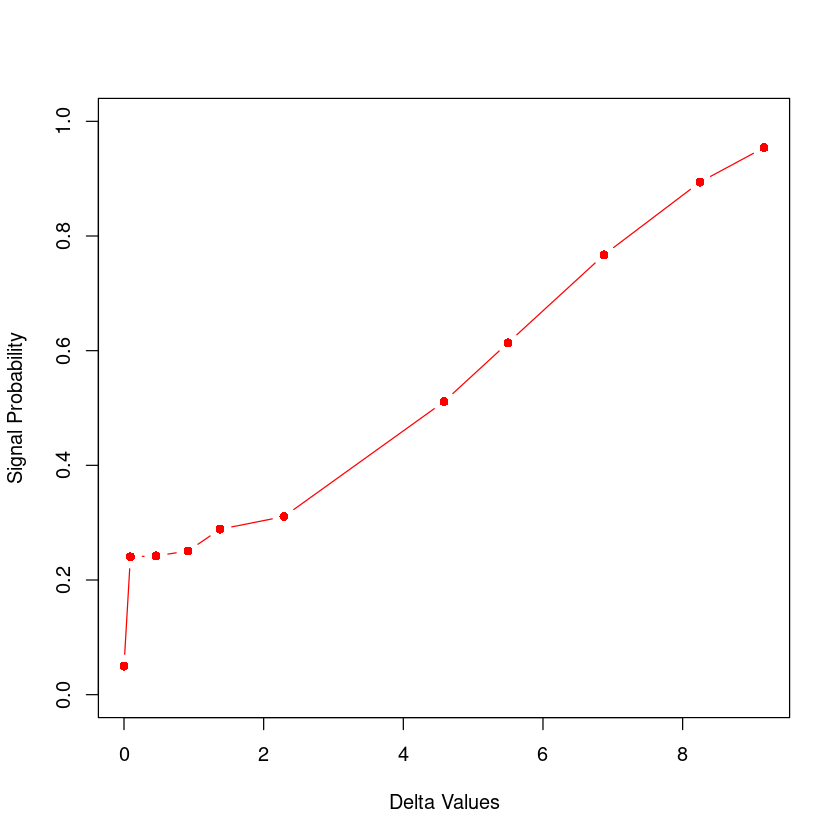

In [28]:
plot(MatrixDeltaMRCD[,1],MatrixDeltaMRCD[,2], ylim = c(0,1), col='red', pch = 16,type='b', xlab ="Delta Values", ylab="Signal Probability",lty = 1)

In [29]:
path <- paste0("/content/SinalprobabilityNormalMC", Observation, "x",
               NumberVariable, "x", Percentoutliers, ".RData")
save.image(path)
drive_upload(path, path = "Colab10000BRPNormal/")

Auto-refreshing stale OAuth token.

Local file:

• /content/SinalprobabilityNormalMC150x250x0.2.RData

Uploaded into Drive file:

• SinalprobabilityNormalMC150x250x0.2.RData
  <id: 1neR4n4-YAknLihmHMhTRdyZilKxJZ6EP>

With MIME type:

• application/x-gzip

